# nanodiffusion Lecture 1: Core Intuition

**Goal**: Understand how generative modeling works by building the simplest possible version.

We'll build everything from scratch, visualize every step, and truly understand what's happening.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device: cuda -> mps -> cpu
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

IMG_SIZE = 16
TIMESTEPS = 100
HIDDEN_DIM = 128
EMBED_DIM = 32

print(f"Device: {DEVICE}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Timesteps: {TIMESTEPS}")

Device: mps
Image size: 16x16
Timesteps: 100


## Part 1: Load and Visualize the Data

We'll use MNIST digits, downscaled to 16x16 for fast training.

Dataset shape: torch.Size([500, 1, 16, 16])
Value range: [-1.00, 1.00]


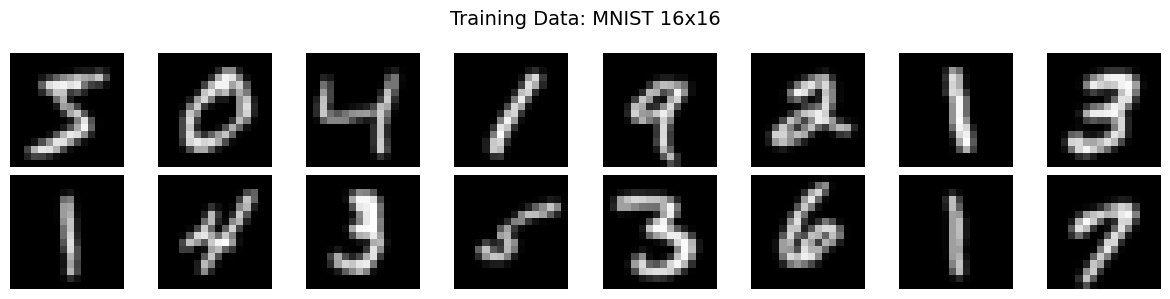

In [17]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Scale to [-1, 1]
])

dataset = datasets.MNIST("../data", train=True, download=True, transform=transform)
images = torch.stack([dataset[i][0] for i in range(500)]).to(DEVICE)

print(f"Dataset shape: {images.shape}")
print(f"Value range: [{images.min():.2f}, {images.max():.2f}]")

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")
plt.suptitle("Training Data: MNIST 16x16", fontsize=14)
plt.tight_layout()
plt.show()

## Part 2: The Core Idea

Generative models learn to **turn noise into data**.

Imagine a line from pure noise (t=0) to clean data (t=1). The model learns: *"At any point on this line, which direction should I go to reach data?"*

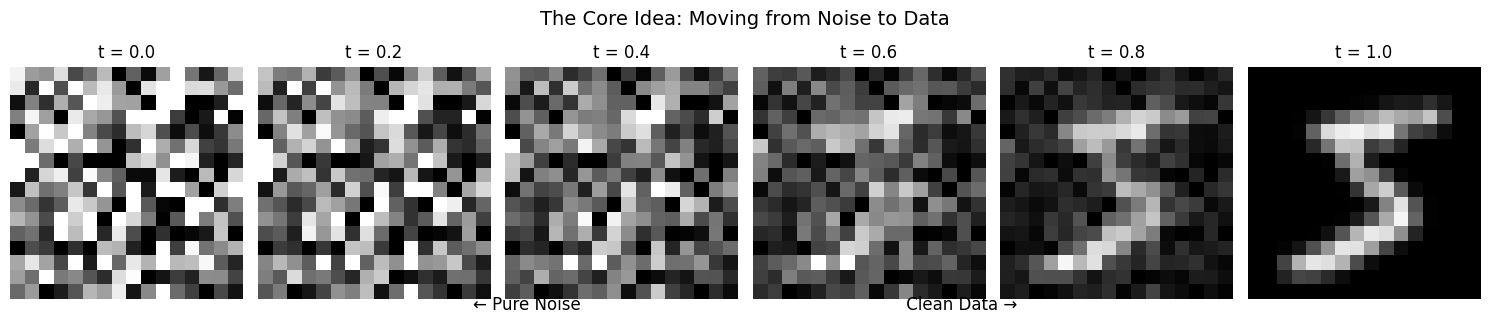

Key insight: If we know which direction to go at each point, we can generate data from noise!


In [18]:
# Visualize the noise-to-data spectrum
x0 = images[0:1]  # One clean image
noise = torch.randn_like(x0)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i, t in enumerate([0.0, 0.2, 0.4, 0.6, 0.8, 1.0]):
    # Linear interpolation: t=0 is noise, t=1 is data
    x_t = (1 - t) * noise + t * x0
    axes[i].imshow(x_t[0].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
    axes[i].set_title(f"t = {t}")
    axes[i].axis("off")

# Add arrow annotation
fig.text(0.5, 0.02, "← Pure Noise                                                              Clean Data →", 
         ha='center', fontsize=12)
plt.suptitle("The Core Idea: Moving from Noise to Data", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Key insight: If we know which direction to go at each point, we can generate data from noise!")

![The Core Idea](diagrams/noise-to-data-line.png)

## Part 3: Two Methods - Side by Side

There are two ways to do this:

| | **DDPM** | **Flow Matching** |
|---|---|---|
| Forward | Complex noise schedule | Simple linear interpolation |
| Predicts | Noise | Velocity (direction) |
| Sampling | 100 steps | 4 steps |

**Same model architecture, different training!** Let's see both.

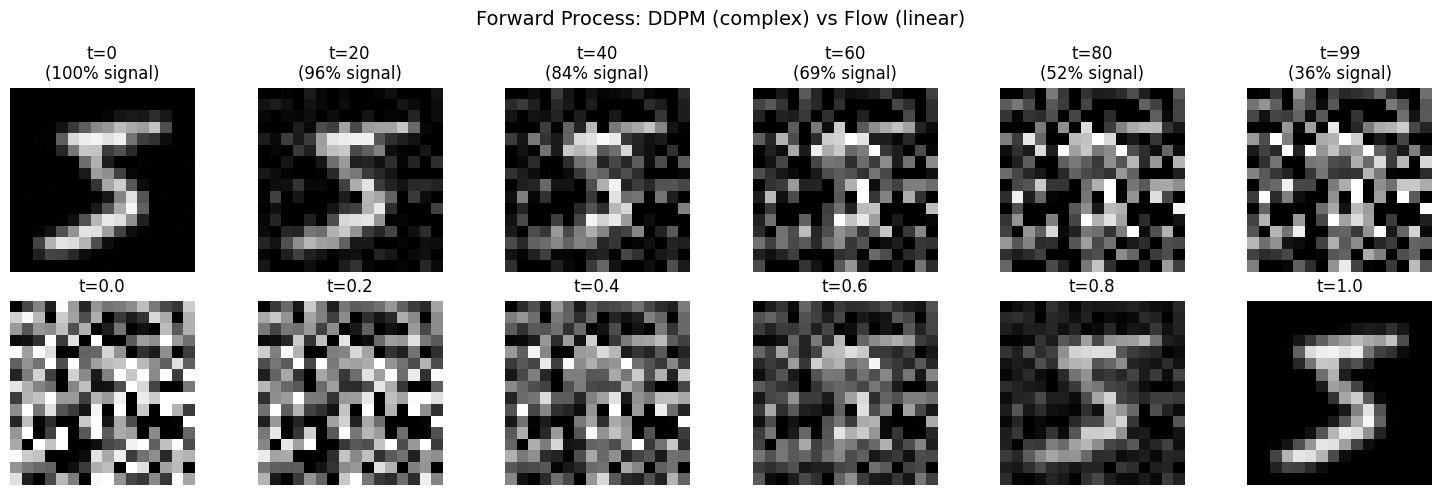

Notice: DDPM t=0 is clean, t=99 is noisy (opposite convention!)
        Flow t=0 is noise, t=1 is clean (intuitive)


In [19]:
# Define both forward processes

# DDPM: Complex schedule
beta = torch.linspace(0.0001, 0.02, TIMESTEPS, device=DEVICE)
alpha = 1 - beta
alpha_bar = alpha.cumprod(dim=0)

def q_sample_ddpm(x0, t, noise):
    """DDPM forward: complex noise schedule."""
    sqrt_alpha_bar = alpha_bar[t].sqrt().view(-1, 1, 1, 1)
    sqrt_one_minus = (1 - alpha_bar[t]).sqrt().view(-1, 1, 1, 1)
    return sqrt_alpha_bar * x0 + sqrt_one_minus * noise

def q_sample_flow(x0, t, noise):
    """Flow matching forward: simple linear interpolation."""
    t = t.view(-1, 1, 1, 1)
    return (1 - t) * noise + t * x0

# Compare them visually
x0 = images[0:1]
noise = torch.randn_like(x0)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# DDPM row (t goes 0 to 99, where 0 = clean, 99 = noisy)
ddpm_times = [0, 20, 40, 60, 80, 99]
for i, t in enumerate(ddpm_times):
    t_tensor = torch.tensor([t], device=DEVICE)
    x_t = q_sample_ddpm(x0, t_tensor, noise)
    axes[0, i].imshow(x_t[0].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
    signal_pct = alpha_bar[t].item() * 100
    axes[0, i].set_title(f"t={t}\n({signal_pct:.0f}% signal)")
    axes[0, i].axis("off")
axes[0, 0].set_ylabel("DDPM", fontsize=14, rotation=0, labelpad=40)

# Flow row (t goes 0 to 1, where 0 = noise, 1 = clean)
flow_times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
for i, t in enumerate(flow_times):
    t_tensor = torch.tensor([t], device=DEVICE)
    x_t = q_sample_flow(x0, t_tensor, noise)
    axes[1, i].imshow(x_t[0].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
    axes[1, i].set_title(f"t={t}")
    axes[1, i].axis("off")
axes[1, 0].set_ylabel("Flow", fontsize=14, rotation=0, labelpad=40)

plt.suptitle("Forward Process: DDPM (complex) vs Flow (linear)", fontsize=14)
plt.tight_layout()
plt.show()

print("Notice: DDPM t=0 is clean, t=99 is noisy (opposite convention!)")
print("        Flow t=0 is noise, t=1 is clean (intuitive)")

![Forward Process Comparison](diagrams/forward-process-comparison.png)

## Part 4: Why Flow is Simpler

Let's look at DDPM's noise schedule in detail. It's carefully designed... but complex.

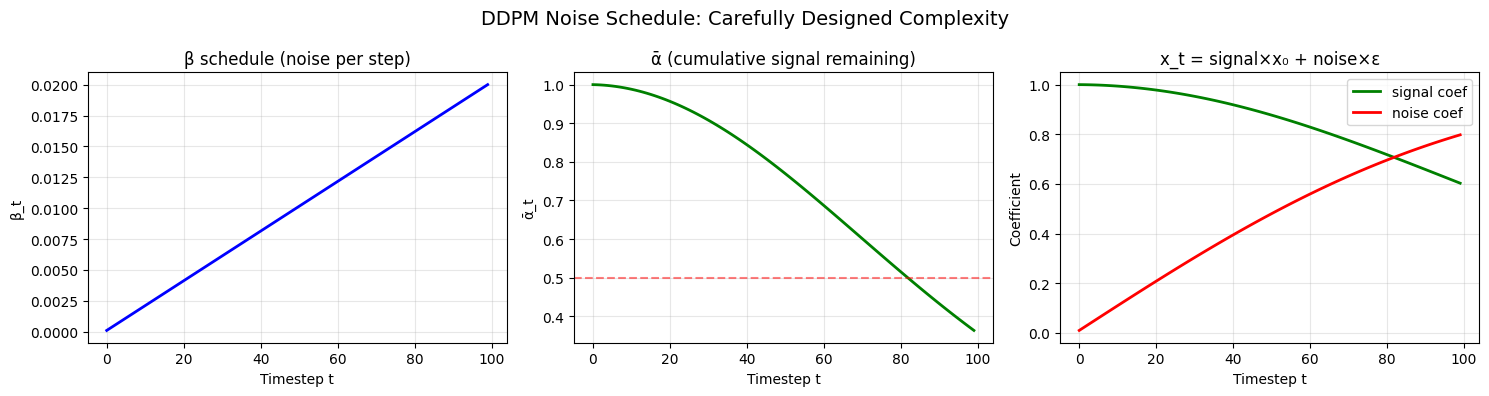

DDPM: x_t = √ᾱ_t × x₀ + √(1-ᾱ_t) × noise
Flow: x_t = (1-t) × noise + t × x₀

Flow is just linear interpolation. No schedule needed!


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Beta schedule (noise added per step)
axes[0].plot(beta.cpu().numpy(), "b-", linewidth=2)
axes[0].set_xlabel("Timestep t")
axes[0].set_ylabel("β_t")
axes[0].set_title("β schedule (noise per step)")
axes[0].grid(True, alpha=0.3)

# Alpha bar (cumulative signal)
axes[1].plot(alpha_bar.cpu().numpy(), "g-", linewidth=2)
axes[1].set_xlabel("Timestep t")
axes[1].set_ylabel("ᾱ_t")
axes[1].set_title("ᾱ (cumulative signal remaining)")
axes[1].axhline(y=0.5, color="r", linestyle="--", alpha=0.5)
axes[1].grid(True, alpha=0.3)

# Signal vs Noise coefficients
sqrt_alpha_bar = alpha_bar.sqrt().cpu().numpy()
sqrt_one_minus = (1 - alpha_bar).sqrt().cpu().numpy()
axes[2].plot(sqrt_alpha_bar, "g-", linewidth=2, label="signal coef")
axes[2].plot(sqrt_one_minus, "r-", linewidth=2, label="noise coef")
axes[2].set_xlabel("Timestep t")
axes[2].set_ylabel("Coefficient")
axes[2].set_title("x_t = signal×x₀ + noise×ε")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("DDPM Noise Schedule: Carefully Designed Complexity", fontsize=14)
plt.tight_layout()
plt.show()

print("DDPM: x_t = √ᾱ_t × x₀ + √(1-ᾱ_t) × noise")
print("Flow: x_t = (1-t) × noise + t × x₀")
print("\nFlow is just linear interpolation. No schedule needed!")

## Part 5: Building the Model

The same U-Net works for both methods! It takes:
- Noisy image (16×16)
- Timestep t

And outputs a prediction (noise for DDPM, velocity for Flow).

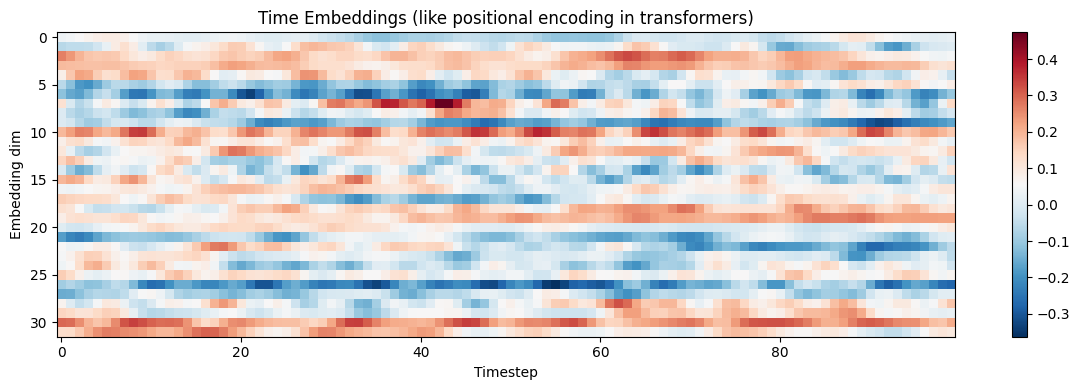

In [21]:
class SinusoidalEmbed(nn.Module):
    """Encode timestep as sinusoidal position embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.fc1 = nn.Linear(dim, dim * 4)
        self.fc2 = nn.Linear(dim * 4, dim)

    def forward(self, t):
        half_dim = self.dim // 2
        emb = torch.log(torch.tensor(10000.0, device=t.device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return self.fc2(F.silu(self.fc1(emb)))

# Visualize time embeddings
time_embed = SinusoidalEmbed(EMBED_DIM).to(DEVICE)
times = torch.linspace(0, TIMESTEPS-1, 100, device=DEVICE)
embeddings = time_embed(times).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(embeddings.T, aspect="auto", cmap="RdBu_r")
ax.set_xlabel("Timestep")
ax.set_ylabel("Embedding dim")
ax.set_title("Time Embeddings (like positional encoding in transformers)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

In [22]:
class ConvBlock(nn.Module):
    """Conv block with time conditioning."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)

    def forward(self, x, t_emb):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.time_proj(t_emb)[:, :, None, None]  # Add time info
        h = F.silu(self.norm2(self.conv2(h)))
        return h


class TinyUNet(nn.Module):
    """Minimal U-Net: encode -> bottleneck -> decode."""
    def __init__(self):
        super().__init__()
        self.time_embed = SinusoidalEmbed(EMBED_DIM)
        
        self.in_block = ConvBlock(1, HIDDEN_DIM, EMBED_DIM)
        self.down1 = nn.Conv2d(HIDDEN_DIM, HIDDEN_DIM, 4, stride=2)  # 16 -> 7
        self.mid_block = ConvBlock(HIDDEN_DIM, HIDDEN_DIM, EMBED_DIM)
        self.up1 = nn.ConvTranspose2d(HIDDEN_DIM, HIDDEN_DIM, 4, stride=2)  # 7 -> 16
        self.out_block = ConvBlock(HIDDEN_DIM, HIDDEN_DIM, EMBED_DIM)
        self.final = nn.Conv2d(HIDDEN_DIM, 1, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        h = self.in_block(x, t_emb)       # [B, 128, 16, 16]
        h = self.down1(h)                  # [B, 128, 7, 7]
        h = self.mid_block(h, t_emb)       # [B, 128, 7, 7]
        h = self.up1(h)                    # [B, 128, 16, 16]
        h = self.out_block(h, t_emb)       # [B, 128, 16, 16]
        return self.final(h)               # [B, 1, 16, 16]


# Test it
model = TinyUNet().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
test_x = torch.randn(4, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
test_t = torch.rand(4, device=DEVICE)
test_out = model(test_x, test_t)

print(f"Model: {n_params:,} parameters")
print(f"Input:  {tuple(test_x.shape)}")
print(f"Output: {tuple(test_out.shape)}")
print("\nArchitecture: 16×16 → 7×7 → 16×16")

Model: 1,286,433 parameters
Input:  (4, 1, 16, 16)
Output: (4, 1, 16, 16)

Architecture: 16×16 → 7×7 → 16×16


![U-Net Architecture](diagrams/unet-architecture.png)

## Part 6: Training Flow Matching (Simpler First!)

Train the model to predict **velocity** = direction from noise to data.

In [23]:
@torch.no_grad()
def sample_flow(model, n=8, steps=4):
    """Generate samples using Euler integration."""
    model.eval()
    x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((n,), i / steps, device=DEVICE)
        x = x + model(x, t) * dt
    model.train()
    return x


def train_flow(model, images, epochs=5, lr=3e-4):
    """Train Flow Matching."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    checkpoints = []
    step = 0
    
    for epoch in range(epochs):
        for _ in range(50):
            idx = torch.randint(0, images.shape[0], (32,))
            x0 = images[idx]
            noise = torch.randn_like(x0)
            
            # Random timestep
            t = torch.rand(x0.shape[0], device=DEVICE)
            
            # Forward: linear interpolation
            x_t = (1 - t.view(-1,1,1,1)) * noise + t.view(-1,1,1,1) * x0
            
            # Target: velocity = data - noise
            velocity = x0 - noise
            
            # Train
            pred = model(x_t, t)
            loss = F.mse_loss(pred, velocity)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
            
            if step % 50 == 0:
                checkpoints.append((step, sample_flow(model, n=8).cpu()))
            step += 1
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(losses[-50:]):.4f}")
    
    return losses, checkpoints


# Train!
model_flow = TinyUNet().to(DEVICE)
print("Training Flow Matching...\n")
flow_losses, flow_checkpoints = train_flow(model_flow, images, epochs=5)

Training Flow Matching...

Epoch 1/5, Loss: 0.8789
Epoch 2/5, Loss: 0.4645
Epoch 3/5, Loss: 0.3841
Epoch 4/5, Loss: 0.3637
Epoch 5/5, Loss: 0.3439


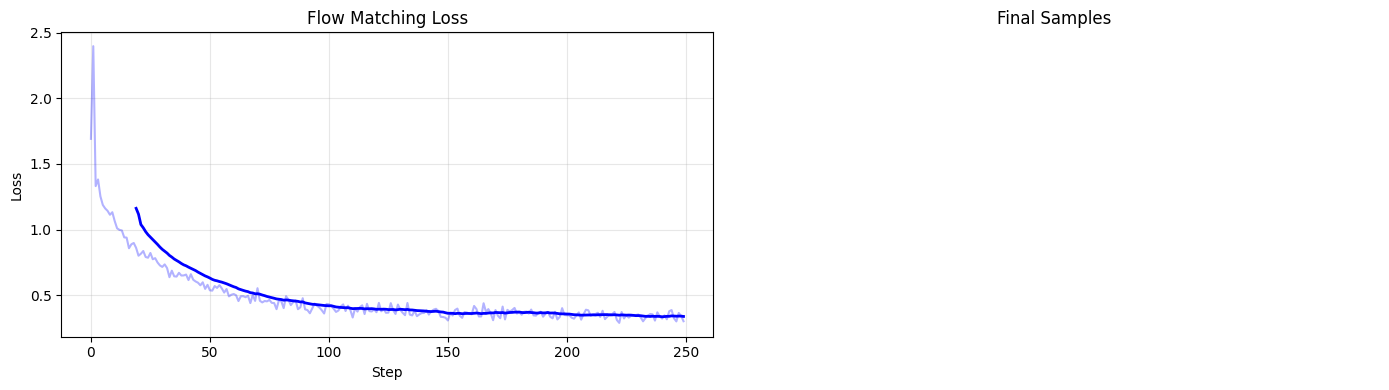

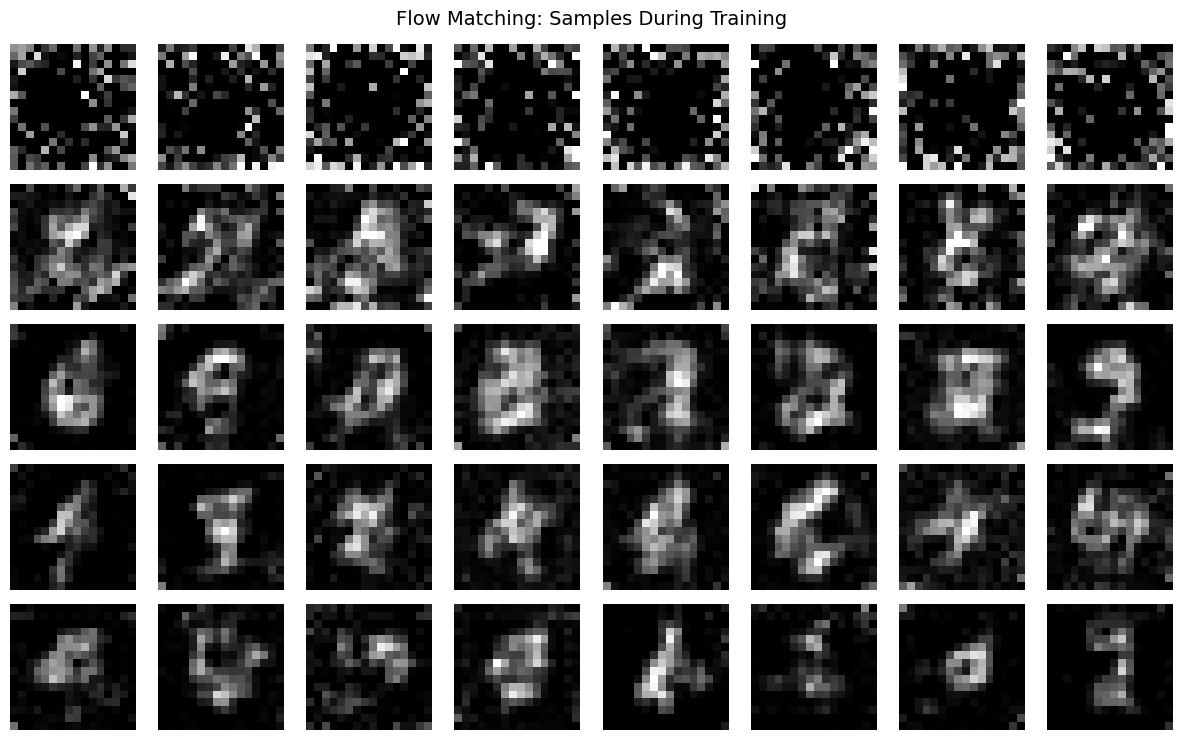

In [24]:
# Visualize training
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
axes[0].plot(flow_losses, alpha=0.3, color="blue")
window = 20
smoothed = np.convolve(flow_losses, np.ones(window)/window, mode="valid")
axes[0].plot(range(window-1, len(flow_losses)), smoothed, "b-", linewidth=2)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Flow Matching Loss")
axes[0].grid(True, alpha=0.3)

# Final samples
axes[1].axis("off")
axes[1].set_title("Final Samples")

plt.tight_layout()
plt.show()

# Show samples at checkpoints
n_show = min(5, len(flow_checkpoints))
indices = [0, len(flow_checkpoints)//4, len(flow_checkpoints)//2, 3*len(flow_checkpoints)//4, -1]
fig, axes = plt.subplots(n_show, 8, figsize=(12, 1.5*n_show))

for row, idx in enumerate(indices[:n_show]):
    step, samples = flow_checkpoints[idx]
    for col in range(8):
        axes[row, col].imshow(samples[col].squeeze(), cmap="gray", vmin=-1, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(f"Step {step}", fontsize=10, rotation=0, labelpad=35)

plt.suptitle("Flow Matching: Samples During Training", fontsize=14)
plt.tight_layout()
plt.show()

![Training Targets](diagrams/training-targets.png)

## Part 7: Training DDPM (For Comparison)

Now let's train DDPM to predict **noise** instead of velocity.

In [25]:
@torch.no_grad()
def sample_ddpm(model, n=8):
    """Generate samples using DDPM reverse process."""
    model.eval()
    x = torch.randn(n, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    
    for t_val in reversed(range(TIMESTEPS)):
        t = torch.full((n,), t_val, device=DEVICE, dtype=torch.float32)
        pred_noise = model(x, t)
        
        alpha_t = alpha[t_val]
        alpha_bar_t = alpha_bar[t_val]
        beta_t = beta[t_val]
        
        mean = (x - beta_t / (1 - alpha_bar_t).sqrt() * pred_noise) / alpha_t.sqrt()
        
        if t_val > 0:
            var = beta_t * (1 - alpha_bar[t_val-1]) / (1 - alpha_bar_t)
            x = mean + var.sqrt() * torch.randn_like(x)
        else:
            x = mean
    
    model.train()
    return x


def train_ddpm(model, images, epochs=5, lr=3e-4):
    """Train DDPM."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = []
    checkpoints = []
    step = 0
    
    for epoch in range(epochs):
        for _ in range(50):
            idx = torch.randint(0, images.shape[0], (32,))
            x0 = images[idx]
            noise = torch.randn_like(x0)
            
            # Random timestep (integer)
            t = torch.randint(0, TIMESTEPS, (x0.shape[0],), device=DEVICE)
            
            # Forward: DDPM schedule
            x_noisy = q_sample_ddpm(x0, t, noise)
            
            # Target: the noise we added
            pred = model(x_noisy, t.float())
            loss = F.mse_loss(pred, noise)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            losses.append(loss.item())
            
            if step % 50 == 0:
                checkpoints.append((step, sample_ddpm(model, n=8).cpu()))
            step += 1
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(losses[-50:]):.4f}")
    
    return losses, checkpoints


# Train!
model_ddpm = TinyUNet().to(DEVICE)
print("Training DDPM...\n")
ddpm_losses, ddpm_checkpoints = train_ddpm(model_ddpm, images, epochs=5)

Training DDPM...

Epoch 1/5, Loss: 0.6353
Epoch 2/5, Loss: 0.2681
Epoch 3/5, Loss: 0.2125
Epoch 4/5, Loss: 0.1895
Epoch 5/5, Loss: 0.1755


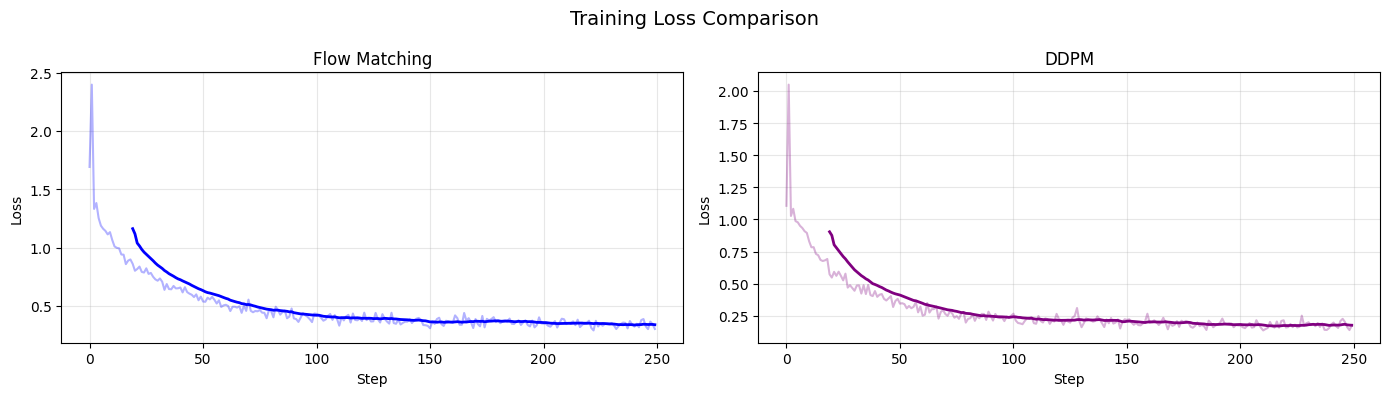

Flow final loss: 0.3439
DDPM final loss: 0.1755


In [26]:
# Compare training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

window = 20

# Flow
axes[0].plot(flow_losses, alpha=0.3, color="blue")
smoothed = np.convolve(flow_losses, np.ones(window)/window, mode="valid")
axes[0].plot(range(window-1, len(flow_losses)), smoothed, "b-", linewidth=2)
axes[0].set_title("Flow Matching")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# DDPM
axes[1].plot(ddpm_losses, alpha=0.3, color="purple")
smoothed = np.convolve(ddpm_losses, np.ones(window)/window, mode="valid")
axes[1].plot(range(window-1, len(ddpm_losses)), smoothed, "purple", linewidth=2)
axes[1].set_title("DDPM")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Training Loss Comparison", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Flow final loss: {np.mean(flow_losses[-50:]):.4f}")
print(f"DDPM final loss: {np.mean(ddpm_losses[-50:]):.4f}")

## Part 8: Final Comparison - Samples & Speed

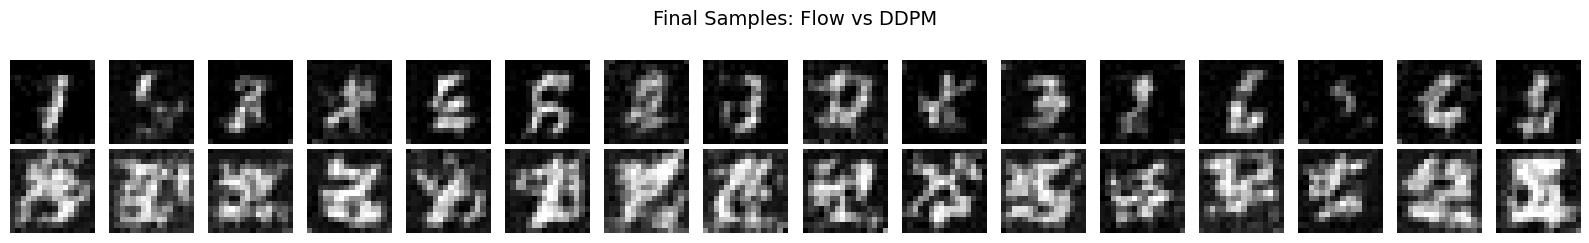


Sampling Time:
  Flow (4 steps):   10.2 ms
  DDPM (100 steps): 226.4 ms
  Speedup: 22.1x


In [27]:
# Generate final samples and measure time

# Flow (4 steps)
t0 = time.time()
flow_samples = sample_flow(model_flow, n=16, steps=4)
flow_time = time.time() - t0

# DDPM (100 steps)
t0 = time.time()
ddpm_samples = sample_ddpm(model_ddpm, n=16)
ddpm_time = time.time() - t0

# Plot
fig, axes = plt.subplots(2, 16, figsize=(16, 2.5))

for i in range(16):
    axes[0, i].imshow(flow_samples[i].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].imshow(ddpm_samples[i].cpu().squeeze(), cmap="gray", vmin=-1, vmax=1)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Flow\n(4 steps)", fontsize=10, rotation=0, labelpad=40)
axes[1, 0].set_ylabel("DDPM\n(100 steps)", fontsize=10, rotation=0, labelpad=40)

plt.suptitle("Final Samples: Flow vs DDPM", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nSampling Time:")
print(f"  Flow (4 steps):   {flow_time*1000:.1f} ms")
print(f"  DDPM (100 steps): {ddpm_time*1000:.1f} ms")
print(f"  Speedup: {ddpm_time/flow_time:.1f}x")

![Sampling Comparison](diagrams/sampling-comparison.png)

## Part 9: Watch the Sampling Process

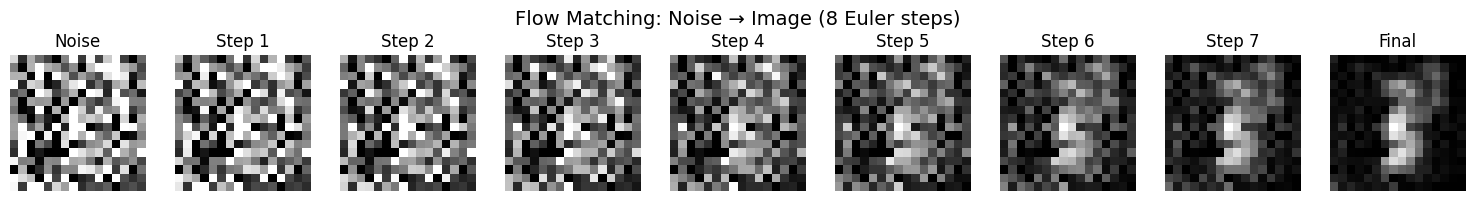

Each step: x = x + velocity × dt
The model predicts which direction to go, and we follow it!


In [28]:
@torch.no_grad()
def sample_flow_trajectory(model, steps=8):
    """Sample and return all intermediate states."""
    model.eval()
    x = torch.randn(1, 1, IMG_SIZE, IMG_SIZE, device=DEVICE)
    trajectory = [x.cpu().clone()]
    dt = 1.0 / steps
    
    for i in range(steps):
        t = torch.full((1,), i / steps, device=DEVICE)
        x = x + model(x, t) * dt
        trajectory.append(x.cpu().clone())
    
    return trajectory

# Get trajectory
trajectory = sample_flow_trajectory(model_flow, steps=8)

# Plot
fig, axes = plt.subplots(1, len(trajectory), figsize=(15, 2))
for i, x in enumerate(trajectory):
    axes[i].imshow(x.squeeze(), cmap="gray", vmin=-1, vmax=1)
    if i == 0:
        axes[i].set_title("Noise")
    elif i == len(trajectory) - 1:
        axes[i].set_title("Final")
    else:
        axes[i].set_title(f"Step {i}")
    axes[i].axis("off")

plt.suptitle("Flow Matching: Noise → Image (8 Euler steps)", fontsize=14)
plt.tight_layout()
plt.show()

print("Each step: x = x + velocity × dt")
print("The model predicts which direction to go, and we follow it!")

## Summary

We built a complete generative model from scratch:

| Step | DDPM | Flow Matching |
|------|------|---------------|
| **Forward** | Complex schedule (α, β) | Linear: `(1-t)×noise + t×data` |
| **Target** | Predict noise | Predict velocity |
| **Sampling** | 100 stochastic steps | 4 Euler steps |
| **Speed** | Slow | **25x faster** |

**Key insight**: Same U-Net, different training wrapper. Flow matching is simpler and faster.

![Full Comparison](diagrams/full-comparison.png)

---

**Next**: See `nanodiffusion.py` for a clean, standalone version.

```bash
cd ~/nanodiffusion
uv sync
uv run python nanodiffusion.py
```